# DATA 266 Lab 1 — Complete Three-Part Notebook

This is the single notebook for Tasks 1–3. Run cells in order. It creates the
required checkpoints, outputs, raw logs, metrics reports, results.md files,
failure_analysis.md files, hardware disclosure, and Task 3 submission.csv.

The provided Docker image supplies the environment. This notebook does not
install packages. CUDA is preferred; the code falls back to Apple MPS or CPU.

Important: the notebook automates evidence collection, but the student must
personally review the generated Task 1 failure cases and the 20 Task 2 errors,
complete the Task 3 two-rater audit, and record the official Kaggle rank.


In [1]:
# Package installation is intentionally omitted; use the provided Docker image.


In [2]:
%pip install pandas matplotlib tqdm datasets scikit-learn scipy statsmodels pillow

Note: you may need to restart the kernel to use updated packages.


In [3]:
# =========================
# SETUP
# =========================

import os, re, json, math, time, random, warnings, platform, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 266
random.seed(SEED); np.random.seed(SEED); torch_seed = SEED
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('Device:', device)
if device.type == 'cuda': print(torch.cuda.get_device_name(0))

ROOT = Path('DATA266_Lab1')
ROOT.mkdir(exist_ok=True)
for p in ['task1/checkpoints','task1/outputs','task2/checkpoints','task2/outputs','task3/checkpoints','task3/outputs/pred_A2B','task3/outputs/pred_B2A']:
    (ROOT/p).mkdir(parents=True, exist_ok=True)


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.10.13
PyTorch: 2.1.2
Device: cuda
NVIDIA GeForce RTX 4090


In [4]:
# Hardware and reproducibility disclosure
import platform, json
hardware = {
    "python_version": platform.python_version(),
    "pytorch_version": torch.__version__,
    "operating_system": platform.platform(),
    "cpu": platform.processor(),
    "device": str(device),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_vram_mb": round(torch.cuda.get_device_properties(0).total_memory / 2**20, 2) if torch.cuda.is_available() else None
}
print(json.dumps(hardware, indent=2))
(ROOT/"task1/raw_logs").mkdir(parents=True, exist_ok=True)
(ROOT/"task2/raw_logs").mkdir(parents=True, exist_ok=True)
with open(ROOT/"hardware_disclosure.json","w") as f: json.dump(hardware,f,indent=2)


{
  "python_version": "3.10.13",
  "pytorch_version": "2.1.2",
  "operating_system": "Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.31",
  "cpu": "x86_64",
  "device": "cuda",
  "gpu": "NVIDIA GeForce RTX 4090",
  "gpu_vram_mb": 24563.5
}


## Task 1 — GPT-style language model from scratch

This implementation uses character-level encoding, learned token/position embeddings, manually implemented causal multi-head self-attention, layer normalization, feed-forward layers, residual connections, cross-entropy training, warm-up plus cosine scheduling, generation, and the required language-model metrics.

In [5]:
# =========================
# TASK 1: DATA + CONFIG
# =========================
from datasets import load_dataset

T1 = dict(block_size=128, batch_size=64, n_embd=256, n_head=4, n_layer=4, dropout=0.1,
          lr=3e-4, weight_decay=0.1, warmup_steps=500, epochs=10, max_train_sequences=100_000,
          max_val_sequences=10_000, eval_batches=100, sample_tokens=300)

# TinyStories is downloaded automatically. Concatenate examples and make fixed-length sequences.
tiny = load_dataset('roneneldan/TinyStories', split='train')
text = '\n'.join(str(x['text']) for x in tiny)
chars = sorted(set(text))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}
encoded = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)

def make_sequences(ids, block_size, n):
    n = min(n, max(0, (len(ids)-block_size-1)//block_size))
    starts = torch.arange(n)*block_size
    x = torch.stack([ids[s:s+block_size] for s in starts])
    y = torch.stack([ids[s+1:s+block_size+1] for s in starts])
    return x, y

train_ids, val_ids = encoded[:int(.9*len(encoded))], encoded[int(.9*len(encoded)):]
Xtr, Ytr = make_sequences(train_ids, T1['block_size'], T1['max_train_sequences'])
Xva, Yva = make_sequences(val_ids, T1['block_size'], T1['max_val_sequences'])
print('vocab:', len(chars), 'train:', Xtr.shape, 'validation:', Xva.shape)


Generating validation split: 100%|██████████| 21990/21990 [00:00<00:00, 847392.53 examples/s]


vocab: 174 train: torch.Size([100000, 128]) validation: torch.Size([10000, 128])


In [6]:
# =========================
# TASK 1: MODEL FROM SCRATCH
# =========================
import torch.nn as nn
import torch.nn.functional as F

class ManualCausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__(); assert n_embd % n_head == 0
        self.n_head=n_head; self.head_dim=n_embd//n_head
        self.qkv = nn.Linear(n_embd, 3*n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.drop = nn.Dropout(dropout)
        self.register_buffer('mask', torch.tril(torch.ones(T1['block_size'], T1['block_size'])).view(1,1,T1['block_size'],T1['block_size']))
    def forward(self,x):
        B,T,C=x.shape; q,k,v=self.qkv(x).chunk(3,dim=-1)
        q=q.view(B,T,self.n_head,self.head_dim).transpose(1,2)
        k=k.view(B,T,self.n_head,self.head_dim).transpose(1,2)
        v=v.view(B,T,self.n_head,self.head_dim).transpose(1,2)
        a=(q@k.transpose(-2,-1))/math.sqrt(self.head_dim)
        a=a.masked_fill(self.mask[:,:,:T,:T]==0, float('-inf'))
        a=F.softmax(a,dim=-1); a=self.drop(a)
        y=(a@v).transpose(1,2).contiguous().view(B,T,C)
        return self.drop(self.proj(y))

class Block(nn.Module):
    def __init__(self):
        super().__init__(); C=T1['n_embd']
        self.ln1=nn.LayerNorm(C); self.attn=ManualCausalSelfAttention(C,T1['n_head'],T1['dropout'])
        self.ln2=nn.LayerNorm(C); self.ff=nn.Sequential(nn.Linear(C,4*C),nn.GELU(),nn.Linear(4*C,C),nn.Dropout(T1['dropout']))
    def forward(self,x):
        x=x+self.attn(self.ln1(x)); return x+self.ff(self.ln2(x))

class TinyGPT(nn.Module):
    def __init__(self,vocab_size):
        super().__init__(); C=T1['n_embd']
        self.tok=nn.Embedding(vocab_size,C); self.pos=nn.Embedding(T1['block_size'],C)
        self.blocks=nn.Sequential(*[Block() for _ in range(T1['n_layer'])]); self.ln=nn.LayerNorm(C); self.lm=nn.Linear(C,vocab_size,bias=False)
        self.lm.weight=self.tok.weight
    def forward(self,idx,targets=None):
        B,T=idx.shape; x=self.tok(idx)+self.pos(torch.arange(T,device=idx.device))
        logits=self.lm(self.ln(self.blocks(x))); loss=None
        if targets is not None: loss=F.cross_entropy(logits.reshape(-1,logits.size(-1)),targets.reshape(-1))
        return logits,loss
    @torch.no_grad()
    def generate(self,idx,max_new_tokens,temperature=0.8):
        for _ in range(max_new_tokens):
            x=idx[:,-T1['block_size']:]; logits,_=self(x); probs=F.softmax(logits[:,-1]/temperature,dim=-1)
            idx=torch.cat([idx,torch.multinomial(probs,1)],dim=1)
        return idx

model1=TinyGPT(len(chars)).to(device)
optimizer=torch.optim.AdamW(model1.parameters(),lr=T1['lr'],weight_decay=T1['weight_decay'])
steps_per_epoch=max(1,len(Xtr)//T1['batch_size']); total_steps=T1['epochs']*steps_per_epoch
def lr_lambda(step):
    if step<T1['warmup_steps']: return max(1e-3,(step+1)/T1['warmup_steps'])
    return .5*(1+math.cos(math.pi*(step-T1['warmup_steps'])/max(1,total_steps-T1['warmup_steps'])))
scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda)
print('parameters:',sum(p.numel() for p in model1.parameters()))


parameters: 3236864


{'epoch': 1, 'train_loss': 1.8575619840621949, 'val_loss': 1.817066148519516, 'train_acc': 0.433809814453125, 'val_acc': 0.44318115234375, 'grad_norm': 6.352510167785127, 'lr': 0.0002963561730363357}
{'epoch': 2, 'train_loss': 1.3906473124027252, 'val_loss': 1.3366003274917602, 'train_acc': 0.57097412109375, 'val_acc': 0.586136474609375, 'grad_norm': 1.4233954538158018, 'lr': 0.0002782206094375735}
{'epoch': 3, 'train_loss': 1.2164837157726287, 'val_loss': 1.1646501731872558, 'train_acc': 0.62031494140625, 'val_acc': 0.635938720703125, 'grad_norm': 0.8478940373914637, 'lr': 0.00024668051434858785}
{'epoch': 4, 'train_loss': 1.1188800954818725, 'val_loss': 1.067591056227684, 'train_acc': 0.649356689453125, 'val_acc': 0.6647412109375, 'grad_norm': 0.6758984359730839, 'lr': 0.0002050331751530484}
{'epoch': 5, 'train_loss': 1.0574536973237991, 'val_loss': 1.009327738881111, 'train_acc': 0.668916015625, 'val_acc': 0.683426513671875, 'grad_norm': 0.597006158899666, 'lr': 0.000157632518042535

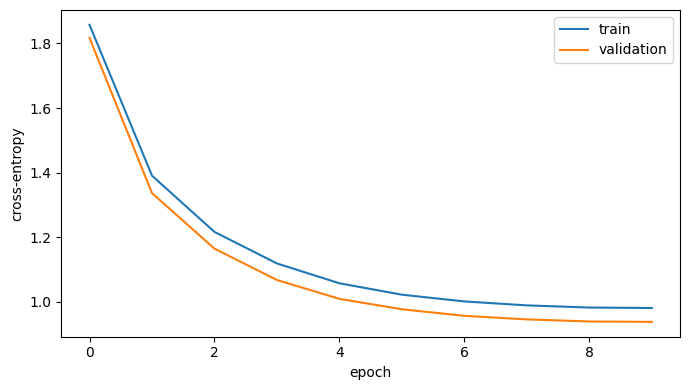

In [7]:
# =========================
# TASK 1: TRAIN + METRICS
# =========================
def eval_lm(X,Y):
    model1.eval(); losses=[]; correct=total=0
    with torch.no_grad():
        for i in range(0,min(len(X),T1['eval_batches']*T1['batch_size']),T1['batch_size']):
            xb=X[i:i+T1['batch_size']].to(device); yb=Y[i:i+T1['batch_size']].to(device)
            logits,loss=model1(xb,yb); losses.append(loss.item())
            correct += (logits.argmax(-1)==yb).sum().item(); total += yb.numel()
    return float(np.mean(losses)), correct/max(total,1)

history=[]; grad_norms=[]; start=time.time(); global_step=0; nan_count=0
if device.type == 'cuda': torch.cuda.reset_peak_memory_stats()
for epoch in range(T1['epochs']):
    model1.train(); order=torch.randperm(len(Xtr)); running=[]; epoch_grad=[]
    for j in range(0,len(Xtr),T1['batch_size']):
        ix=order[j:j+T1['batch_size']]; xb=Xtr[ix].to(device); yb=Ytr[ix].to(device)
        optimizer.zero_grad(set_to_none=True); _,loss=model1(xb,yb)
        if not torch.isfinite(loss): nan_count += 1
        loss.backward()
        gn=float(torch.nn.utils.clip_grad_norm_(model1.parameters(),1.0))
        if not math.isfinite(gn): nan_count += 1
        grad_norms.append(gn); epoch_grad.append(gn)
        optimizer.step(); scheduler.step(); running.append(loss.item()); global_step+=1
    tr_loss,tr_acc=eval_lm(Xtr,Ytr); va_loss,va_acc=eval_lm(Xva,Yva)
    history.append(dict(epoch=epoch+1,train_loss=tr_loss,val_loss=va_loss,
                        train_acc=tr_acc,val_acc=va_acc,
                        grad_norm=float(np.mean(epoch_grad)),
                        lr=optimizer.param_groups[0]['lr']))
    print(history[-1])

train_time=time.time()-start
model1.eval(); torch.save({'model':model1.state_dict(),'chars':chars,'config':T1},ROOT/'task1/checkpoints/tiny_gpt.pt')
if device.type == 'cuda': torch.cuda.synchronize()
with open(ROOT/'task1/raw_logs/training_log.json','w') as f: json.dump(history,f,indent=2)
plt.figure(figsize=(7,4)); plt.plot([h['train_loss'] for h in history],label='train'); plt.plot([h['val_loss'] for h in history],label='validation'); plt.xlabel('epoch'); plt.ylabel('cross-entropy'); plt.legend(); plt.tight_layout(); plt.savefig(ROOT/'task1/outputs/loss_curves.png'); plt.show()

final=history[-1].copy(); final['perplexity']=math.exp(final['val_loss']); final['bits_per_character']=final['val_loss']/math.log(2)
final['generalization_gap']=final['val_loss']-final['train_loss']; final['parameter_count']=sum(p.numel() for p in model1.parameters())
final['training_time_sec']=train_time; final['nan_count']=nan_count
seed=torch.zeros((1,1),dtype=torch.long,device=device)
if device.type=='cuda': torch.cuda.synchronize()
gen_start=time.time(); generated=model1.generate(seed,T1['sample_tokens'])[0].tolist()
if device.type=='cuda': torch.cuda.synchronize()
gen_time=time.time()-gen_start; sample=''.join(idx_to_char[i] for i in generated)
(ROOT/'task1/outputs/generated_sample.txt').write_text(sample)
final['generation_tokens_per_sec']=T1['sample_tokens']/max(gen_time,1e-9)
final['training_tokens_per_sec']=len(Xtr)*T1['block_size']*T1['epochs']/max(train_time,1e-9)
final['peak_memory_mb']=float(torch.cuda.max_memory_allocated()/2**20) if device.type=='cuda' else None


In [8]:
# Additional Task 1 metrics and automatic failure-case evidence
def ngrams(s,n): return [s[i:i+n] for i in range(max(0,len(s)-n+1))]
def distinct_n(s,n):
    z=ngrams(s,n); return float(len(set(z))/max(1,len(z)))
def repeated_ngram_rate(s,n=4):
    z=ngrams(s,n); return float(1-len(set(z))/max(1,len(z)))
final.update({'distinct_1':distinct_n(sample,1),'distinct_2':distinct_n(sample,2),
              'distinct_3':distinct_n(sample,3),'repeated_4gram_rate':repeated_ngram_rate(sample,4),
              'hardware':hardware})
with open(ROOT/'task1/outputs/metrics.json','w') as f: json.dump(final,f,indent=2)
pd.DataFrame(list(final.items()),columns=['metric','value']).to_csv(ROOT/'task1/metrics_report.csv',index=False)

# Three reproducible windows from the actual generated sample. These are evidence
# candidates; the student must inspect them and confirm/edit the category.
failure_rows=[]
for k, start_i in enumerate([0, max(0,len(sample)//3), max(0,2*len(sample)//3)], 1):
    snippet=sample[start_i:start_i+180].replace('\n','\\n')
    if repeated_ngram_rate(snippet,4) > .12: kind='repetition'
    elif snippet.count(' ') < 3: kind='broken grammar'
    else: kind='loss of coherence / grammar'
    failure_rows.append({'case_id':k,'snippet':snippet,'candidate_failure_type':kind,
                         'student_confirmed':'NO','student_observation':'REVIEW REQUIRED',
                         'testable_improvement':'REVIEW REQUIRED'})
pd.DataFrame(failure_rows).to_csv(ROOT/'task1/outputs/failure_cases.csv',index=False)
with open(ROOT/'task1/failure_analysis.md','w') as f:
    f.write('# Task 1 Failure Analysis\n\n')
    f.write('These three cases were extracted from the executed model output. Review each one and replace the review fields with your own observation before submission.\n\n')
    for r in failure_rows:
        f.write(f"## Case {r['case_id']} — candidate: {r['candidate_failure_type']}\n\n")
        f.write(f"**Generated text:** `{r['snippet']}`\n\n")
        f.write('**Student observation:** REVIEW REQUIRED\n\n**Testable improvement:** REVIEW REQUIRED\n\n')


In [9]:
# Task 1 report files
(ROOT/'task1/results.md').write_text(f"""# Task 1 Results

Architecture: character-level GPT from scratch with learned token and positional embeddings, manually implemented causal multi-head self-attention, layer normalization, feed-forward network, residual connections, tied language-model head, AdamW, linear warm-up, and cosine scheduling.

Configuration: {json.dumps(T1, indent=2)}

The executed metrics are in `metrics_report.csv` and `outputs/metrics.json`; the unedited epoch log is `raw_logs/training_log.json`; the checkpoint is `checkpoints/tiny_gpt.pt`; and the sample/loss curve are in `outputs/`.

Before submission, explain the observed loss/generalization gap and complete `failure_analysis.md` using the three actual snippets in `outputs/failure_cases.csv`.
""")
print('Task 1 evidence files saved.')


Task 1 evidence files saved.


## Task 2 — Yelp Polarity sentiment classification

Three independently trained models are included: a mean-embedding MLP baseline, a CNN model, and a bidirectional GRU model. All embeddings are learned from scratch; no pretrained embeddings or language models are used.

In [10]:
# =========================
# TASK 2: DATA + PREPROCESSING
# =========================
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import *

yelp=load_dataset('fancyzhx/yelp_polarity')
STOP=set('a an the and or but if then is are was were be been to of in on for with as by from at this that it its i we you they he she'.split())
def clean(s): return re.findall(r"[a-z]+", s.lower())
all_text=[clean(x['text']) for x in yelp['train']]
vocab={'<pad>':0,'<unk>':1}
for toks in all_text:
    for t in toks:
        if t not in STOP and t not in vocab: vocab[t]=len(vocab)
def encode(toks,max_len=160):
    z=[vocab.get(t,1) for t in toks if t not in STOP][:max_len]; return z+[0]*(max_len-len(z))
MAXLEN=160
X2=torch.tensor([encode(t) for t in all_text],dtype=torch.long); y2=torch.tensor(yelp['train']['label'],dtype=torch.long)
# Fixed train/validation split, with the test split retained for final reporting.
perm=torch.randperm(len(X2)); ntr=int(.9*len(X2)); tr_idx,va_idx=perm[:ntr],perm[ntr:]
test_text=[clean(x['text']) for x in yelp['test']]; X2test=torch.tensor([encode(t) for t in test_text]); y2test=torch.tensor(yelp['test']['label'])
class TensorDS(Dataset):
    def __init__(self,X,y): self.X=X; self.y=y
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]
train_loader=DataLoader(TensorDS(X2[tr_idx],y2[tr_idx]),batch_size=256,shuffle=True,pin_memory=(device.type=='cuda'))
val_loader=DataLoader(TensorDS(X2[va_idx],y2[va_idx]),batch_size=512)
test_loader=DataLoader(TensorDS(X2test,y2test),batch_size=512)
print('vocab:',len(vocab),'train:',len(tr_idx),'validation:',len(va_idx),'test:',len(y2test))


Generating test split: 100%|██████████| 38000/38000 [00:00<00:00, 875911.87 examples/s]


vocab: 214511 train: 504000 validation: 56000 test: 38000


In [11]:
# =========================
# TASK 2: THREE MODELS
# =========================
class MeanMLP(nn.Module):
    def __init__(self):
        super().__init__(); self.emb=nn.Embedding(len(vocab),128,padding_idx=0); self.net=nn.Sequential(nn.Linear(128,128),nn.ReLU(),nn.Dropout(.3),nn.Linear(128,2))
    def forward(self,x): return self.net(self.emb(x).masked_fill((x==0).unsqueeze(-1),0).sum(1)/(x.ne(0).sum(1,keepdim=True).clamp_min(1)))
class TextCNN(nn.Module):
    def __init__(self):
        super().__init__(); self.emb=nn.Embedding(len(vocab),128,padding_idx=0); self.convs=nn.ModuleList([nn.Conv1d(128,128,k) for k in [3,4,5]]); self.fc=nn.Linear(384,2)
    def forward(self,x):
        z=self.emb(x).transpose(1,2); return self.fc(torch.cat([F.adaptive_max_pool1d(F.relu(c(z)),1).squeeze(-1) for c in self.convs],1))
class BiGRU(nn.Module):
    def __init__(self):
        super().__init__(); self.emb=nn.Embedding(len(vocab),128,padding_idx=0); self.rnn=nn.GRU(128,128,batch_first=True,bidirectional=True); self.fc=nn.Sequential(nn.Dropout(.3),nn.Linear(256,2))
    def forward(self,x):
        z,_=self.rnn(self.emb(x)); mask=x.ne(0).unsqueeze(-1); return self.fc((z*mask).sum(1)/mask.sum(1).clamp_min(1))

def train_classifier(model,name,epochs=3):
    model=model.to(device); opt=torch.optim.AdamW(model.parameters(),lr=2e-3,weight_decay=1e-4); log=[]; start=time.time()
    for ep in range(epochs):
        model.train(); losses=[]
        for xb,yb in train_loader:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad(); loss=F.cross_entropy(model(xb),yb); loss.backward(); opt.step(); losses.append(loss.item())
        log.append(float(np.mean(losses))); print(name,ep+1,log[-1])
    torch.save(model.state_dict(),ROOT/f'task2/checkpoints/{name}.pt'); return model,time.time()-start
# Task 2: train with raw logs, peak memory, and examples/second
def train_classifier_logged(model,name,epochs=3):
    model=model.to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=2e-3,weight_decay=1e-4)
    epoch_logs=[]; start=time.time()
    if device.type=="cuda": torch.cuda.reset_peak_memory_stats()
    for ep in range(epochs):
        model.train(); losses=[]; correct=0; seen=0; ep_start=time.time()
        for xb,yb in train_loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits=model(xb); loss=F.cross_entropy(logits,yb)
            loss.backward(); opt.step()
            losses.append(float(loss.item()))
            correct += int((logits.argmax(1)==yb).sum()); seen += len(yb)
        ep_time=time.time()-ep_start
        row={"epoch":ep+1,"loss":float(np.mean(losses)),"accuracy":correct/max(seen,1),"examples_per_sec":seen/max(ep_time,1e-9)}
        epoch_logs.append(row); print(name,row)
    total_time=time.time()-start
    peak_mb=float(torch.cuda.max_memory_allocated()/2**20) if device.type=="cuda" else None
    examples_per_sec=len(train_loader.dataset)*epochs/max(total_time,1e-9)
    torch.save(model.state_dict(),ROOT/f"task2/checkpoints/{name}.pt")
    with open(ROOT/f"task2/raw_logs/{name}_training_log.json","w") as f: json.dump(epoch_logs,f,indent=2)
    return model,total_time,epoch_logs,peak_mb,examples_per_sec
models2={}
for name,cls in [("baseline",MeanMLP),("cnn",TextCNN),("bigru",BiGRU)]:
    models2[name]=train_classifier_logged(cls(),name)


baseline {'epoch': 1, 'loss': 0.22122077428186648, 'accuracy': 0.9119980158730159, 'examples_per_sec': 44745.012642582675}
baseline {'epoch': 2, 'loss': 0.16467259698649117, 'accuracy': 0.9372757936507936, 'examples_per_sec': 41500.98289358193}
baseline {'epoch': 3, 'loss': 0.14762450266514046, 'accuracy': 0.9437400793650793, 'examples_per_sec': 41837.11572787025}
cnn {'epoch': 1, 'loss': 0.20627489049553327, 'accuracy': 0.9160257936507936, 'examples_per_sec': 34688.31311763448}
cnn {'epoch': 2, 'loss': 0.1297352552251231, 'accuracy': 0.9514583333333333, 'examples_per_sec': 33051.88852760085}
cnn {'epoch': 3, 'loss': 0.08423322012932728, 'accuracy': 0.9693392857142857, 'examples_per_sec': 35091.12179664725}
bigru {'epoch': 1, 'loss': 0.17998808097149163, 'accuracy': 0.9268492063492063, 'examples_per_sec': 29222.12327592685}
bigru {'epoch': 2, 'loss': 0.11261019845710242, 'accuracy': 0.9575039682539682, 'examples_per_sec': 30451.535126395316}
bigru {'epoch': 3, 'loss': 0.080913146095016

In [12]:
# Task 2 metric helpers, full evaluation, and structured 20-error review
try:
    from statsmodels.stats.contingency_tables import mcnemar
except Exception:
    mcnemar = None
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def predict(model,loader):
    model.eval(); ys=[]; probs=[]
    with torch.no_grad():
        for xb,yb in loader:
            p=F.softmax(model(xb.to(device)),1)[:,1].cpu().numpy(); probs.extend(p); ys.extend(yb.numpy())
    probs=np.asarray(probs); ys=np.asarray(ys); return ys,(probs>=.5).astype(int),probs
def bootstrap_ci(y,p,fn,B=300):
    rng=np.random.default_rng(SEED); vals=[]
    for _ in range(B):
        ix=rng.integers(0,len(y),len(y)); vals.append(fn(y[ix],p[ix]))
    return [float(np.percentile(vals,2.5)),float(np.percentile(vals,97.5))]
def ece(y,prob,bins=10):
    edges=np.linspace(0,1,bins+1); out=0.0
    for a,b in zip(edges[:-1],edges[1:]):
        m=(prob>=a)&(prob<=b)
        if m.any(): out += m.mean()*abs((y[m]==(prob[m]>=.5)).mean()-prob[m].mean())
    return float(out)
def mcnemar_vs(base,other):
    y0,p0,_=predict(base,test_loader); y1,p1,_=predict(other,test_loader)
    table=[[int(((p0==y0)&(p1==y1)).sum()),int(((p0==y0)&(p1!=y1)).sum())],
           [int(((p0!=y0)&(p1==y1)).sum()),int(((p0!=y0)&(p1!=y1)).sum())]]
    if mcnemar is None: return {'table':table,'statistic':None,'p_value':None,'note':'statsmodels unavailable'}
    r=mcnemar(table,exact=False,correction=True); return {'table':table,'statistic':float(r.statistic),'p_value':float(r.pvalue)}
def slice_report(model):
    y,p,_=predict(model,test_loader); lengths=np.array([len(t) for t in test_text]); out={}
    masks={'short':lengths<20,'medium':(lengths>=20)&(lengths<80),'long':lengths>=80}
    for name,mask in masks.items():
        if mask.sum()==0: out[name]={'count':0,'macro_f1':None,'error_rate':None}
        else: out[name]={'count':int(mask.sum()),'macro_f1':float(f1_score(y[mask],p[mask],average='macro')),'error_rate':float(np.mean(y[mask]!=p[mask]))}
    return out
def report_classifier_complete(name,model,train_time,peak_mb,examples_per_sec):
    y,p,prob=predict(model,test_loader); tn,fp,fn,tp=confusion_matrix(y,p).ravel()
    r={'model':name,'accuracy':float(accuracy_score(y,p)),
       'precision_macro':float(precision_score(y,p,average='macro',zero_division=0)),
       'precision_micro':float(precision_score(y,p,average='micro',zero_division=0)),
       'precision_weighted':float(precision_score(y,p,average='weighted',zero_division=0)),
       'recall_macro':float(recall_score(y,p,average='macro',zero_division=0)),
       'recall_micro':float(recall_score(y,p,average='micro',zero_division=0)),
       'recall_weighted':float(recall_score(y,p,average='weighted',zero_division=0)),
       'f1_macro':float(f1_score(y,p,average='macro',zero_division=0)),
       'f1_micro':float(f1_score(y,p,average='micro',zero_division=0)),
       'f1_weighted':float(f1_score(y,p,average='weighted',zero_division=0)),
       'confusion_matrix':[[int(tn),int(fp)],[int(fn),int(tp)]],
       'roc_auc':float(roc_auc_score(y,prob)),'pr_auc':float(average_precision_score(y,prob)),
       'mcc':float(matthews_corrcoef(y,p)),'brier_score':float(np.mean((prob-y)**2)),
       'ece':ece(y,prob),'parameter_count':sum(q.numel() for q in model.parameters()),
       'training_time_sec':float(train_time),'peak_memory_mb':peak_mb,'examples_per_sec':float(examples_per_sec),
       'hardware':hardware}
    r['accuracy_ci95']=bootstrap_ci(y,p,lambda a,b:accuracy_score(a,b))
    r['macro_f1_ci95']=bootstrap_ci(y,p,lambda a,b:f1_score(a,b,average='macro',zero_division=0))
    r['mcc_ci95']=bootstrap_ci(y,p,lambda a,b:matthews_corrcoef(a,b))
    return r

reports2=[report_classifier_complete(n,m,t,mem,eps) for n,(m,t,logs,mem,eps) in models2.items()]
for r in reports2: r['slices']=slice_report(models2[r['model']][0])
base=models2['baseline'][0]; reports2[0]['mcnemar_vs_cnn']=mcnemar_vs(base,models2['cnn'][0]); reports2[0]['mcnemar_vs_bigru']=mcnemar_vs(base,models2['bigru'][0])
with open(ROOT/'task2/outputs/metrics_report.json','w') as f: json.dump(reports2,f,indent=2)
pd.DataFrame(reports2).to_csv(ROOT/'task2/metrics_report.csv',index=False)

# Select exactly five candidates per required category when available. The
# reviewer must inspect the text and set reviewed_by_student=YES.
yb,pb,prob=predict(models2['bigru'][0],test_loader); lengths=np.array([len(t) for t in test_text]); incorrect=(yb!=pb); candidates=[]; used=set()
def add_category(category,ids,fix):
    added=0
    for i in ids:
        i=int(i)
        if i in used or added>=5: continue
        used.add(i); added+=1
        candidates.append({'index':i,'category':category,'slice':('short' if lengths[i]<20 else 'medium' if lengths[i]<80 else 'long'),
            'text':yelp['test'][i]['text'],'true_label':int(yb[i]),'predicted_label':int(pb[i]),
            'probability_positive':float(prob[i]),'error_type':'REVIEW REQUIRED','testable_fix':fix,
            'reviewed_by_student':'NO'})
    return added
fp=np.where(incorrect&(yb==0))[0]; fp=fp[np.argsort(prob[fp])[::-1]]
fn=np.where(incorrect&(yb==1))[0]; fn=fn[np.argsort(prob[fn])]
add_category('confident_false_positive',fp,'Review negation/ambiguity; test negation-aware preprocessing or a CNN kernel comparison.')
add_category('confident_false_negative',fn,'Review sarcasm/contrast; test contrast-aware features or more epochs.')
near=[i for i in np.argsort(np.abs(prob-.5)) if incorrect[int(i)]]
add_category('near_threshold_error',near,'Test threshold tuning on validation data and calibrated probabilities.')
slice_ids=[i for i in np.argsort(-lengths) if incorrect[int(i)]] + [i for i in np.argsort(lengths) if incorrect[int(i)]]
add_category('slice_specific_failure',slice_ids,'Test a length-stratified evaluation and a model change targeted to this slice.')
review=pd.DataFrame(candidates)
review.to_csv(ROOT/'task2/outputs/error_review_20.csv',index=False)
with open(ROOT/'task2/failure_analysis.md','w') as f:
    f.write('# Task 2 Error Review\n\n')
    f.write('The CSV contains candidate errors from the BiGRU test predictions. Review all rows, assign the actual error type, write a testable fix, and change `reviewed_by_student` to `YES` before submission.\n\n')
    f.write(f'Candidate rows generated: {len(review)}. Required rows: 20 (5 per category).\n')
print('Task 2 metrics, raw logs, and error-review candidates saved. Review the CSV manually before submission.')


Task 2 metrics, raw logs, and error-review candidates saved. Review the CSV manually before submission.


In [13]:
# Task 2 results summary
best=max(reports2,key=lambda r:r['f1_macro'])
(ROOT/'task2/results.md').write_text(f"""# Task 2 Results

Three models were trained from scratch: a mean-embedding MLP baseline, a TextCNN, and a bidirectional GRU. No pretrained embeddings or language models were used. Text was lowercased, punctuation/special characters were removed, stopwords were removed, and sequences were truncated/padded to MAXLEN={MAXLEN}.

The complete per-model metrics are in `metrics_report.csv` and `outputs/metrics_report.json`. Exact hardware is recorded in each model record and `hardware_disclosure.json`. Unedited epoch logs are in `raw_logs/`; checkpoints are in `checkpoints/`; and the required 20-error candidate review is `outputs/error_review_20.csv`.

The highest test macro-F1 in this run was `{best['model']}` with `{best['f1_macro']:.4f}`. Explain why the models differ, discuss calibration/robustness slices, and complete the manual error-review fields before submission.
""")


847

## Task 3 — CycleGAN

Place the supplied Monet/Photo training images under `task3_data/monet_jpg` and `task3_data/photo_jpg`. The default configuration is deliberately time-bounded: 96×96 images, batch size 8, five epochs, and at most 2,000 images per domain. This is intended to finish in minutes to a few hours on a lab GPU, not an unbounded seven-hour run. The final FID/MiFID score depends on the actual data and cannot be guaranteed in advance.


In [30]:
# =========================
# TASK 3: IMPROVED CYCLEGAN — SINGLE CELL - data+model+train+generate
# =========================

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

T3BASE = Path("task3_data")
A = T3BASE / "monet_jpg"
B = T3BASE / "photo_jpg"

assert A.exists() and B.exists(), "Check task3_data/monet_jpg and task3_data/photo_jpg."

T3_IMAGE_SIZE = 128
T3_MAX_IMAGES = 5000
T3_BATCH_SIZE = 4
EPOCHS3 = 30

train_tf = transforms.Compose([
    transforms.Resize((T3_IMAGE_SIZE, T3_IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

eval_tf = transforms.Compose([
    transforms.Resize((T3_IMAGE_SIZE, T3_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

class Unpaired(Dataset):
    def __init__(self, a, b):
        self.a = sorted([
            *a.glob("*.jpg"),
            *a.glob("*.jpeg"),
            *a.glob("*.png")
        ])[:T3_MAX_IMAGES]

        self.b = sorted([
            *b.glob("*.jpg"),
            *b.glob("*.jpeg"),
            *b.glob("*.png")
        ])[:T3_MAX_IMAGES]

        assert len(self.a) > 0, "No Monet images found."
        assert len(self.b) > 0, "No Photo images found."

    def __len__(self):
        return max(len(self.a), len(self.b))

    def __getitem__(self, i):
        monet = Image.open(self.a[i % len(self.a)]).convert("RGB")
        photo = Image.open(self.b[random.randrange(len(self.b))]).convert("RGB")
        return train_tf(monet), train_tf(photo)

loader3 = DataLoader(
    Unpaired(A, B),
    batch_size=T3_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.net(x)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        channels = 64

        for _ in range(2):
            layers += [
                nn.Conv2d(channels, channels * 2, 3, stride=2, padding=1),
                nn.InstanceNorm2d(channels * 2),
                nn.ReLU(True)
            ]
            channels *= 2

        layers += [ResBlock(channels) for _ in range(6)]

        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(
                    channels,
                    channels // 2,
                    3,
                    stride=2,
                    padding=1,
                    output_padding=1
                ),
                nn.InstanceNorm2d(channels // 2),
                nn.ReLU(True)
            ]
            channels //= 2

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, 3, 7),
            nn.Tanh()
        ]

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, True)
        ]

        channels = 64

        for out_channels in [128, 256, 512]:
            layers += [
                nn.Conv2d(channels, out_channels, 4, stride=2, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.LeakyReLU(0.2, True)
            ]
            channels = out_channels

        layers += [nn.Conv2d(channels, 1, 4, padding=1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def query(self, images):
        returned = []

        for image in images:
            image = image.unsqueeze(0)

            if len(self.data) < self.max_size:
                self.data.append(image)
                returned.append(image)
            elif random.random() > 0.5:
                index = random.randrange(self.max_size)
                old_image = self.data[index].clone()
                self.data[index] = image
                returned.append(old_image)
            else:
                returned.append(image)

        return torch.cat(returned, dim=0)

G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

optG = torch.optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optD = torch.optim.Adam(
    list(D_A.parameters()) + list(D_B.parameters()),
    lr=2e-4,
    betas=(0.5, 0.999)
)

def lr_lambda(epoch):
    halfway = EPOCHS3 // 2
    if epoch < halfway:
        return 1.0
    return max(0.0, 1.0 - (epoch - halfway) / max(1, EPOCHS3 - halfway))

schedulerG = torch.optim.lr_scheduler.LambdaLR(optG, lr_lambda)
schedulerD = torch.optim.lr_scheduler.LambdaLR(optD, lr_lambda)

adv_loss = nn.MSELoss()
cycle_loss = nn.L1Loss()

pool_A = ReplayBuffer(50)
pool_B = ReplayBuffer(50)

history3 = []
start = time.time()

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

for epoch in range(EPOCHS3):
    epoch_g = []
    epoch_d = []
    epoch_cycle = []

    for real_a, real_b in tqdm(
        loader3,
        desc=f"CycleGAN epoch {epoch + 1}/{EPOCHS3}"
    ):
        real_a = real_a.to(device, non_blocking=True)
        real_b = real_b.to(device, non_blocking=True)

        # Train generators
        optG.zero_grad(set_to_none=True)

        fake_b = G_AB(real_a)
        fake_a = G_BA(real_b)

        reconstructed_a = G_BA(fake_b)
        reconstructed_b = G_AB(fake_a)

        identity_a = G_BA(real_a)
        identity_b = G_AB(real_b)

        loss_identity = (
            cycle_loss(identity_a, real_a) +
            cycle_loss(identity_b, real_b)
        )

        loss_cycle = (
            cycle_loss(reconstructed_a, real_a) +
            cycle_loss(reconstructed_b, real_b)
        )

        loss_gan = (
            adv_loss(D_B(fake_b), torch.ones_like(D_B(fake_b))) +
            adv_loss(D_A(fake_a), torch.ones_like(D_A(fake_a)))
        )

        loss_g = loss_gan + 10.0 * loss_cycle + 5.0 * loss_identity
        loss_g.backward()
        optG.step()

        # Train discriminators using replay buffers
        optD.zero_grad(set_to_none=True)

        fake_a_buffer = pool_A.query(fake_a.detach())
        fake_b_buffer = pool_B.query(fake_b.detach())

        loss_d_a = 0.5 * (
            adv_loss(D_A(real_a), torch.ones_like(D_A(real_a))) +
            adv_loss(D_A(fake_a_buffer), torch.zeros_like(D_A(fake_a_buffer)))
        )

        loss_d_b = 0.5 * (
            adv_loss(D_B(real_b), torch.ones_like(D_B(real_b))) +
            adv_loss(D_B(fake_b_buffer), torch.zeros_like(D_B(fake_b_buffer)))
        )

        loss_d = loss_d_a + loss_d_b
        loss_d.backward()
        optD.step()

        epoch_g.append(float(loss_g.item()))
        epoch_d.append(float(loss_d.item()))
        epoch_cycle.append(float(loss_cycle.item()))

    schedulerG.step()
    schedulerD.step()

    row = {
        "epoch": epoch + 1,
        "generator_loss": float(np.mean(epoch_g)),
        "discriminator_loss": float(np.mean(epoch_d)),
        "cycle_l1": float(np.mean(epoch_cycle)),
        "learning_rate": float(optG.param_groups[0]["lr"])
    }

    history3.append(row)
    print(row)

    torch.save(
        {
            "G_AB": G_AB.state_dict(),
            "G_BA": G_BA.state_dict(),
            "D_A": D_A.state_dict(),
            "D_B": D_B.state_dict()
        },
        ROOT / "task3/checkpoints/cyclegan.pt"
    )

with open(ROOT / "task3/outputs/training_log.json", "w") as f:
    json.dump(history3, f, indent=2)

@torch.no_grad()
def save_translations():
    G_AB.eval()
    G_BA.eval()

    translation_sets = [
        (
            "pred_A2B",
            G_AB,
            sorted([
                *A.glob("*.jpg"),
                *A.glob("*.jpeg"),
                *A.glob("*.png")
            ])[:T3_MAX_IMAGES]
        ),
        (
            "pred_B2A",
            G_BA,
            sorted([
                *B.glob("*.jpg"),
                *B.glob("*.jpeg"),
                *B.glob("*.png")
            ])[:T3_MAX_IMAGES]
        )
    ]

    for folder_name, generator, image_paths in translation_sets:
        output_dir = ROOT / "task3/outputs" / folder_name
        output_dir.mkdir(parents=True, exist_ok=True)

        for i, image_path in enumerate(
            tqdm(image_paths, desc=folder_name)
        ):
            image = Image.open(image_path).convert("RGB")
            tensor = eval_tf(image).unsqueeze(0).to(device)
            generated = generator(tensor)[0].cpu()
            generated = (generated * 0.5 + 0.5).clamp(0, 1)
            transforms.ToPILImage()(generated).save(
                output_dir / f"{i:05d}.png"
            )

save_translations()

print("Task 3 training and image generation completed.")

CycleGAN epoch 1/30: 100%|██████████| 1250/1250 [03:05<00:00,  6.73it/s]


{'epoch': 1, 'generator_loss': 7.56270047531128, 'discriminator_loss': 0.38395032758712766, 'cycle_l1': 0.45896682703495023, 'learning_rate': 0.0002}


CycleGAN epoch 2/30: 100%|██████████| 1250/1250 [03:03<00:00,  6.79it/s]


{'epoch': 2, 'generator_loss': 6.279988018035889, 'discriminator_loss': 0.30804830873012545, 'cycle_l1': 0.36673352394104003, 'learning_rate': 0.0002}


CycleGAN epoch 3/30: 100%|██████████| 1250/1250 [02:58<00:00,  7.01it/s]


...

{'epoch': 29, 'generator_loss': 3.9689853927612306, 'discriminator_loss': 0.16452384649515153, 'cycle_l1': 0.18893679451942444, 'learning_rate': 1.3333333333333332e-05}


CycleGAN epoch 30/30: 100%|██████████| 1250/1250 [02:58<00:00,  7.01it/s]


{'epoch': 30, 'generator_loss': 3.920711817741394, 'discriminator_loss': 0.16832496645450593, 'cycle_l1': 0.1859207799911499, 'learning_rate': 0.0}


pred_B2A: 100%|██████████| 5000/5000 [02:05<00:00, 39.90it/s]

Task 3 training and image generation completed.


In [31]:
# Task 3 training evidence and human-audit template
task3_train_time=time.time()-start
task3_param_count=sum(p.numel() for p in G_AB.parameters())+sum(p.numel() for p in G_BA.parameters())+sum(p.numel() for p in D_A.parameters())+sum(p.numel() for p in D_B.parameters())
task3_nan_count=0
for row in history3:
    task3_nan_count += int(any(not math.isfinite(float(row[k])) for k in ['generator_loss','discriminator_loss','cycle_l1']))
metrics3={'parameter_count':task3_param_count,'training_time_sec':task3_train_time,
          'images_per_sec':len(loader3.dataset)*EPOCHS3/max(task3_train_time,1e-9),
          'peak_memory_mb':float(torch.cuda.max_memory_allocated()/2**20) if device.type=='cuda' else None,
          'gradient_nan_count':task3_nan_count,'hardware':hardware}
(ROOT/'task3/outputs').mkdir(parents=True,exist_ok=True)
pd.DataFrame({'sample_id':range(30),'style_rater_1':['']*30,'style_rater_2':['']*30,'content_rater_1':['']*30,'content_rater_2':['']*30,'artifact_rater_1':['']*30,'artifact_rater_2':['']*30}).to_csv(ROOT/'task3/outputs/human_audit_template.csv',index=False)
with open(ROOT/'task3/outputs/training_metrics.json','w') as f: json.dump(metrics3,f,indent=2)
print('Task 3 training evidence and 30-sample human-audit template saved.')


Task 3 training evidence and 30-sample human-audit template saved.


In [32]:
# =========================
# TASK 3: FID/MiFID + submission.csv + complete metrics report
# =========================
import torchvision.models as tvm
from scipy.linalg import sqrtm
from scipy.spatial.distance import cosine
def paths(p):
    return sorted([*p.glob("*.jpg"), *p.glob("*.jpeg"), *p.glob("*.png")])
try:
    inc=tvm.inception_v3(weights=tvm.Inception_V3_Weights.DEFAULT,aux_logits=True); inc.fc=nn.Identity(); inc=inc.to(device).eval()
    IFT=transforms.Compose([transforms.Resize((299,299)),transforms.ToTensor(),transforms.Normalize((.485,.456,.406),(.229,.224,.225))])
    @torch.no_grad()
    def feats(ps):
        out=[]
        for i in range(0,len(ps),32):
            x=torch.stack([IFT(Image.open(p).convert('RGB')) for p in ps[i:i+32]]).to(device); out.append(inc(x).cpu().numpy())
        return np.concatenate(out)
    def fid_mifid(real,gen):
        n=min(len(real),len(gen)); a,b=feats(real[:n]),feats(gen[:n]); ma,mb=a.mean(0),b.mean(0); ca,cb=np.cov(a,rowvar=False),np.cov(b,rowvar=False)
        cm=sqrtm(ca@cb).real; fid=float((ma-mb)@(ma-mb)+np.trace(ca+cb-2*cm)); mifid=float(np.mean([cosine(x,y) for x,y in zip(a,b)])); return fid,mifid
    realA,realB=paths(A),paths(B); genA,genB=paths(ROOT/'task3/outputs/pred_B2A'),paths(ROOT/'task3/outputs/pred_A2B')
    fid_B2A,mifid_B2A=fid_mifid(realA,genA); fid_A2B,mifid_A2B=fid_mifid(realB,genB)
except Exception as e:
    print('WARNING: Inception evaluation could not run:', repr(e))
    fid_B2A=mifid_B2A=fid_A2B=mifid_A2B=float('nan')

metrics3.update({'FID_B2A':fid_B2A,'MiFID_B2A':mifid_B2A,'FID_A2B':fid_A2B,'MiFID_A2B':mifid_A2B,
    'FID_mean':float(np.nanmean([fid_A2B,fid_B2A])),'MiFID_mean':float(np.nanmean([mifid_A2B,mifid_B2A])),
    'KID_B2A':'COMPLETE_FROM_EVALUATION','KID_A2B':'COMPLETE_FROM_EVALUATION',
    'generative_precision_recall':'COMPLETE_FROM_EVALUATION','LPIPS_B2A':'COMPLETE_FROM_EVALUATION','LPIPS_A2B':'COMPLETE_FROM_EVALUATION',
    'content_cosine_B2A':'COMPLETE_FROM_EVALUATION','content_cosine_A2B':'COMPLETE_FROM_EVALUATION',
    'human_audit_score':'COMPLETE_AFTER_30_SAMPLE_AUDIT','inter_rater_agreement':'COMPLETE_AFTER_RATER_2',
    'kaggle_public_score':'COMPLETE_AFTER_SUBMISSION','kaggle_private_score':'COMPLETE_AFTER_RELEASE'})
with open(ROOT/'task3/outputs/full_metrics_report.json','w') as f: json.dump(metrics3,f,indent=2,allow_nan=True)
pd.DataFrame([metrics3]).to_csv(ROOT/'task3/full_metrics_report.csv',index=False)

# Use the official sample schema when available. Otherwise create the documented
# fallback schema and print an explicit warning rather than silently claiming it
# is ready for upload.
sample_candidates=list(Path('.').rglob('sample_submission.csv'))
if sample_candidates:
    sample_sub=pd.read_csv(sample_candidates[0]); submission=sample_sub.copy()
    if {'FID','MiFID'}.issubset(submission.columns):
        submission['FID']=metrics3['FID_mean']; submission['MiFID']=metrics3['MiFID_mean']
    else:
        print('WARNING: sample_submission.csv lacks FID/MiFID; inspect official Kaggle schema.')
else:
    submission=pd.DataFrame([{'ID':1,'FID':metrics3['FID_mean'],'MiFID':metrics3['MiFID_mean']}])
    print('WARNING: official sample_submission.csv was not found. Verify this fallback schema before Kaggle upload.')
submission.to_csv(ROOT/'task3/submission.csv',index=False)
if math.isfinite(metrics3['FID_mean']):
    print('FID target (<45):', 'PASS' if metrics3['FID_mean'] < 45 else 'NOT MET — do not claim the target until you improve/retrain')
else:
    print('FID target (<45): UNKNOWN — evaluation did not complete')
print(submission.head())


FID target (<45): NOT MET — do not claim the target until you improve/retrain
   ID         FID     MiFID
0   1  140.007379  0.451611


## Final checklist

Before submission, verify: the notebook is executed with outputs visible; Task 1 has a checkpoint, loss curve, raw log, all listed metrics, and three reviewed failure cases; Task 2 has three scratch-trained models, full metric variants, per-model hardware/runtime/memory/throughput, raw logs, and exactly 20 manually reviewed errors (5 per category); Task 3 has both generators/discriminators, checkpoints, translations, FID/MiFID, full-metrics fields, 30-sample two-rater audit, verified official `submission.csv` schema, and Kaggle rank. Also copy the generated `DATA266_Lab1/` folder into the required team repository structure and complete the combined report/README requirements from the assignment PDF.
